<a href="https://colab.research.google.com/github/mathusalini/Facial-Emotion-Recognition/blob/main/Facial_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Output (Capture again to update). To stop: Interrupt runtime.


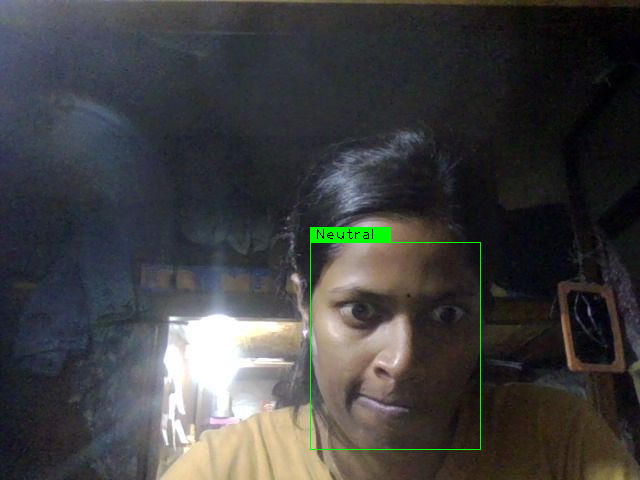

<IPython.core.display.Javascript object>

In [ ]:
# ==============================
# 1) INSTALL
# ==============================
!pip -q install facial-emotion-recognition opencv-python-headless

# ==============================
# 2) IMPORT + SAFE TORCH CPU PATCH
# ==============================
import torch

# If torch.load was patched before, restore the original (kept in torch.serialization)
torch.load = torch.serialization.load

# Now patch safely (only once)
def cpu_only_load(*args, **kwargs):
    kwargs["map_location"] = torch.device("cpu")
    return torch.serialization.load(*args, **kwargs)

torch.load = cpu_only_load

from facial_emotion_recognition import EmotionRecognition
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

# ==============================
# 3) WEBCAM CAPTURE
# ==============================
def take_photo(quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const btn = document.createElement('button');
          btn.textContent = '📸 Capture Frame';
          btn.style.fontSize = '18px';
          btn.style.padding = '10px';
          btn.style.margin = '10px 0px';
          div.appendChild(btn);

          const video = document.createElement('video');
          video.style.display = 'block';
          video.style.border = '2px solid #444';
          video.style.borderRadius = '10px';
          video.width = 640;

          document.body.appendChild(div);
          div.appendChild(video);

          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => btn.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js(f"takePhoto({quality})")
    binary = b64decode(data.split(",")[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return frame

# ==============================
# 4) INIT MODEL (CPU)
# ==============================
er = EmotionRecognition(device="cpu")

# ==============================
# 5) LOOP (LIVE-LIKE)
# ==============================
print("✅ Ready! Allow webcam permission. Click 'Capture Frame' each time.")

while True:
    frame = take_photo(quality=0.8)
    out = er.recognise_emotion(frame, return_type="BGR")

    clear_output(wait=True)
    print("✅ Output (Capture again to update). To stop: Interrupt runtime.")
    cv2_imshow(out)

    time.sleep(0.2)